# Singularized Mixup Demo on CIFAR-10

This notebook is a compact presentation demo for **singularized mixup** as a privacy-preserving data transformation.

The goal is to show four things quickly:

- what clean CIFAR-10 samples look like;
- how singularized mixup changes samples in image space;
- why a simple known-partner reconstruction works on noiseless mixup but fails on singularized mixup;
- how feature-space singularization fits into the repository training pipeline, with memory and timing measurements.

## Core Formula

For an anchor sample $(x_i, y_i)$ and a partner sample $(x_j, y_j)$, singularized mixup forms

$$
\tilde{x}_i = \lambda_i x_i + (1 - \lambda_i)(x_j + e_i)
$$

$$
\tilde{y}_i = \lambda_i y_i + (1 - \lambda_i)y_j .
$$

The privacy-relevant difference from ordinary two-sample mixup is the perturbation $e_i$ attached to the partner component before mixing.

In [1]:
import time
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

from utils import (
    DEFAULT_SEED,
    DenseClassifier,
    build_resnet_feature_extractor,
    compute_c_factor,
    cross_entropy_with_soft_targets,
    estimate_average_distance,
    estimate_per_pixel_variance_global_mean,
    get_optimal_device,
    mf_from_tau,
    mixup_batch_in_feature_space,
    sample_ball_noise,
    set_deterministic_behavior,
)

set_deterministic_behavior(DEFAULT_SEED)
device = get_optimal_device()
print(f"Device: {device}")

Device: mps


## Demo Configuration

We use CIFAR-10 for visuals and a frozen ImageNet-pretrained ResNet-18 for feature-space experiments. The image-space visuals use tensors in $[0, 1]$ so they are easy to display. The feature-space path uses ImageNet normalization, matching the repository training code.

In [2]:
NUM_VIS = 5
BATCH_SIZE = 64
TIMING_BATCH_SIZE = 128
TAU = 1e-3
ALPHA_MAX = 0.7
LAM_FIXED = 0.6

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

tfm_display = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
])

tfm_resnet = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

display_train = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=tfm_display
)
resnet_train = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=tfm_resnet
)
resnet_test = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=tfm_resnet
)

vis_indices = [0, 1, 2, 3, 4]
partner_indices = [5, 6, 7, 8, 9]

anchors = torch.stack([display_train[i][0] for i in vis_indices])
anchor_labels = torch.tensor([display_train[i][1] for i in vis_indices])
partners = torch.stack([display_train[i][0] for i in partner_indices])
partner_labels = torch.tensor([display_train[i][1] for i in partner_indices])

print("Anchor labels:", [CIFAR10_CLASSES[i] for i in anchor_labels.tolist()])
print("Partner labels:", [CIFAR10_CLASSES[i] for i in partner_labels.tolist()])

Anchor labels: ['frog', 'truck', 'truck', 'deer', 'automobile']
Partner labels: ['automobile', 'bird', 'horse', 'ship', 'cat']


In [3]:
def to_img_np(x):
    return x.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()


def show_row(images, titles, figsize=(16, 3), suptitle=None):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(to_img_np(img))
        ax.set_title(title, fontsize=11)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()


def show_grid(rows, row_labels, col_labels, figsize=(15, 10)):
    nrows, ncols = len(rows), len(rows[0])
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    for r in range(nrows):
        for c in range(ncols):
            axes[r, c].imshow(to_img_np(rows[r][c]))
            axes[r, c].axis("off")
            if r == 0:
                axes[r, c].set_title(col_labels[c], fontsize=11)
            if c == 0:
                axes[r, c].set_ylabel(row_labels[r], fontsize=11)
    plt.tight_layout()
    plt.show()


def tensor_memory_mb(tensor):
    return tensor.numel() * tensor.element_size() / (1024 ** 2)


def sync_if_needed():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    if hasattr(torch, "mps") and torch.backends.mps.is_available():
        torch.mps.synchronize()

## Five Clean CIFAR-10 Samples

These are ordinary CIFAR-10 images after resizing for the ResNet pipeline. They are the anchor samples reused in the next visualizations.

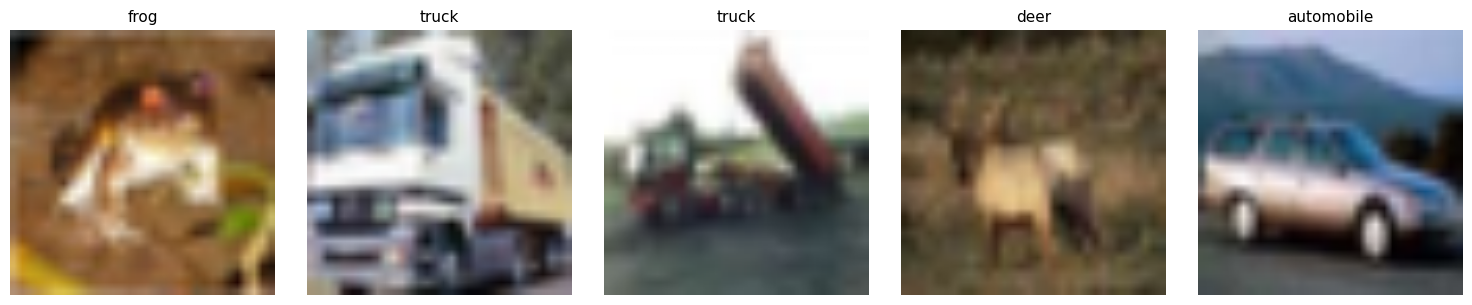

In [4]:
show_row(
    [anchors[i] for i in range(NUM_VIS)],
    [CIFAR10_CLASSES[int(anchor_labels[i])] for i in range(NUM_VIS)],
    figsize=(15, 3),
)

## Image-Space Singularized Mixup

For visualization, we apply the same idea directly in image space. The partner is perturbed with fixed-L2 noise and then mixed with the anchor. Smaller $\tau$ means stronger noise; here we use one fixed value to keep the demo readable.

In [5]:
@torch.no_grad()
def sample_fixed_l2_noise_like(x, target_norm):
    noise = torch.randn_like(x)
    flat = noise.flatten(1)
    norms = flat.norm(p=2, dim=1).clamp_min(1e-12)
    return noise * (target_norm / norms).view(-1, 1, 1, 1)


@torch.no_grad()
def image_space_singularized_mixup(anchor, partner, lam, noise_norm):
    noise = sample_fixed_l2_noise_like(partner, noise_norm)
    noisy_partner = (partner + noise).clamp(0, 1)
    mixed = (lam * anchor + (1.0 - lam) * noisy_partner).clamp(0, 1)
    return mixed, noisy_partner, noise


stats_subset = Subset(display_train, list(range(512)))
r_img = estimate_average_distance(stats_subset, device=device, max_images=512, batch_size=64)
v_hat, d_img = estimate_per_pixel_variance_global_mean(stats_subset, device=device, max_images=512, batch_size=64)
c_img = compute_c_factor(r_img, v_hat, d_img)
mf = mf_from_tau(alpha=ALPHA_MAX, tau=TAU, c=c_img)
# Use a capped display norm to keep the live visual readable while preserving the noisy-partner idea.
theory_noise_norm = mf * r_img
display_noise_norm = min(theory_noise_norm, 35.0)

mixed_imgs, noisy_partners, image_noise = image_space_singularized_mixup(
    anchors, partners, LAM_FIXED, display_noise_norm
)

print(f"tau={TAU:g} | r={r_img:.3f} | c={c_img:.3f} | mf={mf:.3f}")
print(f"Theoretical noise norm mf*r={theory_noise_norm:.3f}; displayed norm={display_noise_norm:.3f}")

tau=0.001 | r=128.682 | c=0.919 | mf=54.428
Theoretical noise norm mf*r=7003.887; displayed norm=35.000


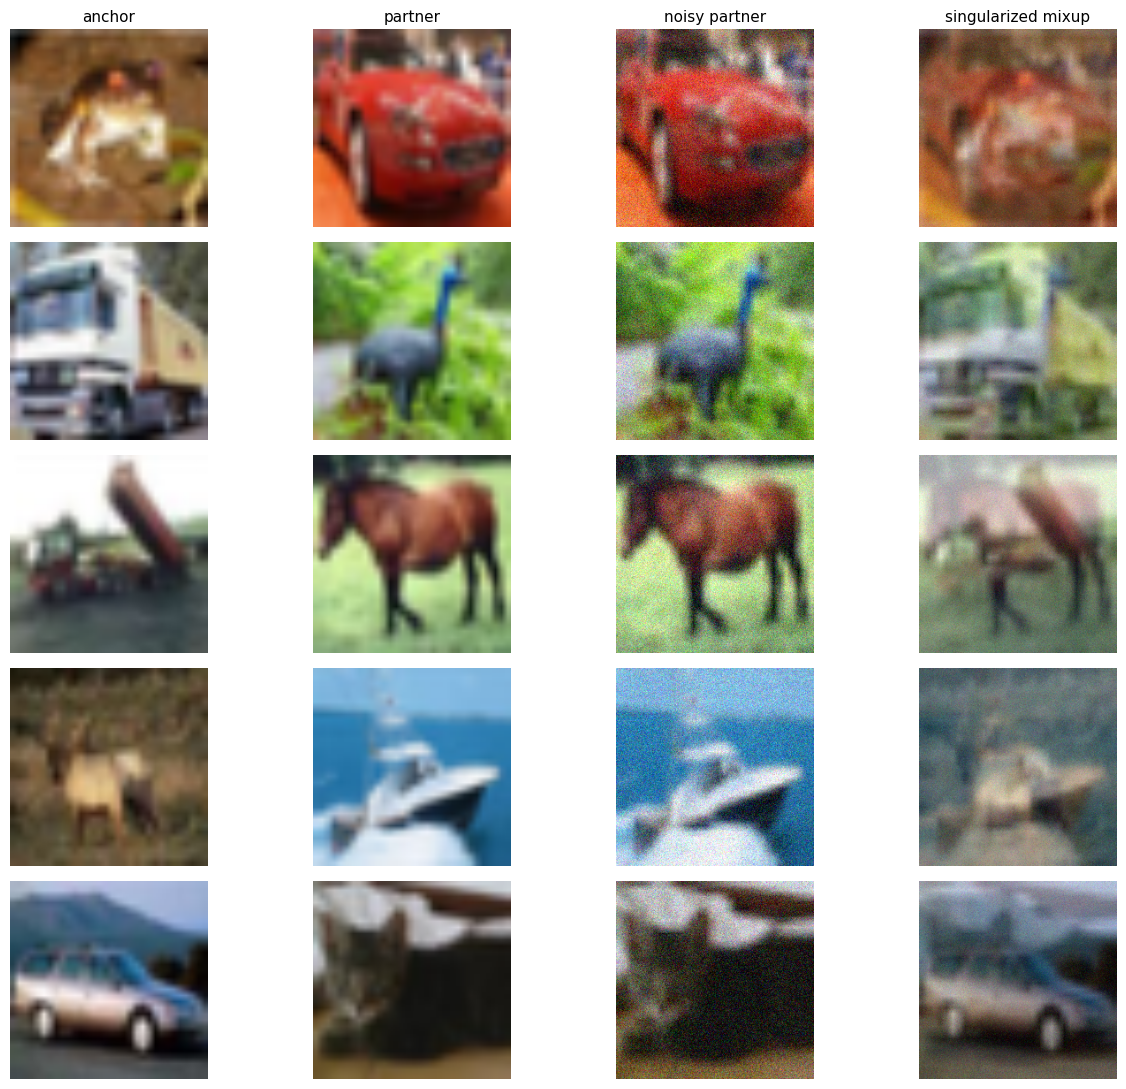

In [6]:
rows = []
row_labels = []
for i in range(NUM_VIS):
    rows.append([anchors[i], partners[i], noisy_partners[i], mixed_imgs[i]])
    row_labels.append(f"sample {i+1}")

show_grid(
    rows,
    row_labels=row_labels,
    col_labels=["anchor", "partner", "noisy partner", "singularized mixup"],
    figsize=(13, 11),
)

## Simple Known-Partner Reconstruction Attack

A deliberately simple attack illustrates the role of the noise term.

For ordinary noiseless two-sample mixup, if the attacker knows the partner and coefficient, then

$$
m = \lambda x_i + (1 - \lambda)x_j
$$

can be inverted as

$$
\hat{x}_i = \frac{m - (1 - \lambda)x_j}{\lambda}.
$$

For singularized mixup, the same operation returns

$$
\hat{x}_i = x_i + \frac{1 - \lambda}{\lambda} e_i,
$$

so unknown noise is amplified into the reconstruction.

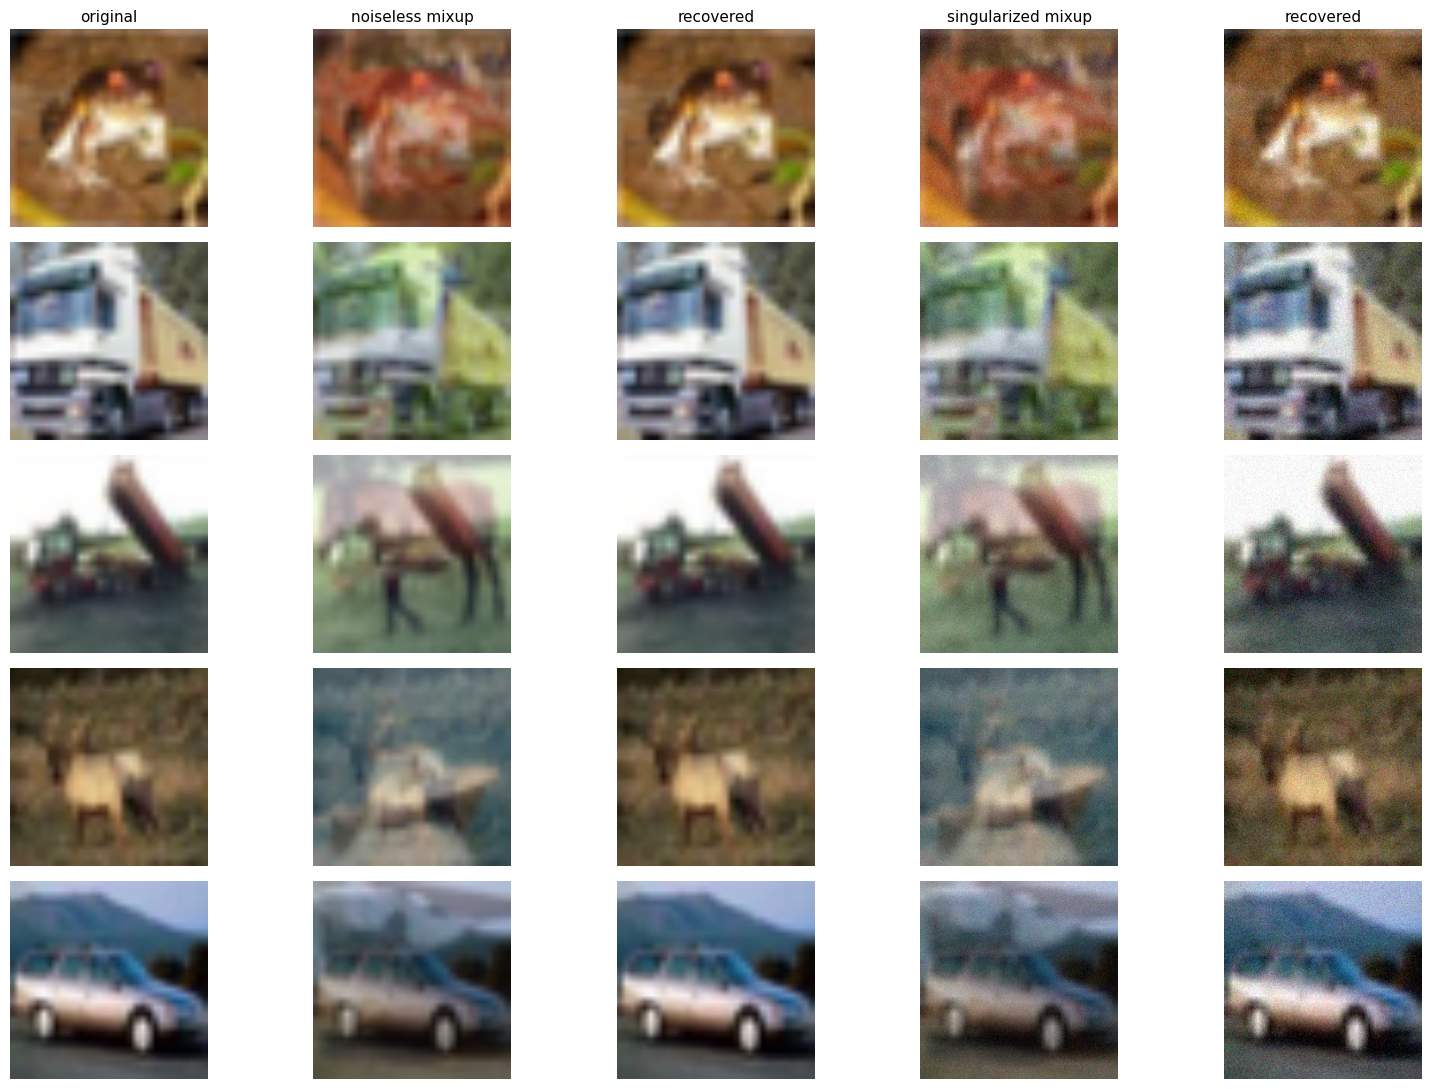

In [7]:
@torch.no_grad()
def known_partner_reconstruct(mixed, known_partner, lam):
    return ((mixed - (1.0 - lam) * known_partner) / lam).clamp(0, 1)


noiseless_mix = (LAM_FIXED * anchors + (1.0 - LAM_FIXED) * partners).clamp(0, 1)
recovered_noiseless = known_partner_reconstruct(noiseless_mix, partners, LAM_FIXED)
recovered_singularized = known_partner_reconstruct(mixed_imgs, partners, LAM_FIXED)

attack_rows = []
for i in range(NUM_VIS):
    attack_rows.append([
        anchors[i],
        noiseless_mix[i],
        recovered_noiseless[i],
        mixed_imgs[i],
        recovered_singularized[i],
    ])

show_grid(
    attack_rows,
    row_labels=[f"sample {i+1}" for i in range(NUM_VIS)],
    col_labels=["original", "noiseless mixup", "recovered", "singularized mixup", "recovered"],
    figsize=(16, 11),
)

## Feature-Space Singularized Mixup

The repository's main training path applies the same two-sample noisy-partner principle in feature space, after a frozen pretrained backbone.

Feature vectors are not natural images. For the demo, we visualize feature maps as channel grids: each small tile is one activation channel.

In [8]:
feature_extractor = build_resnet_feature_extractor("resnet18", device)
feature_extractor.eval()

resnet_vis_imgs = torch.stack([resnet_train[i][0] for i in vis_indices])
resnet_vis_labels = torch.tensor([resnet_train[i][1] for i in vis_indices])

with torch.no_grad():
    clean_fmap = feature_extractor(resnet_vis_imgs.to(device)).detach().cpu()

# A modest radius keeps the feature-grid contrast readable in a live notebook.
feature_radius_for_demo = 50.0
mix_feats, mix_soft_labels = mixup_batch_in_feature_space(
    feature_extractor,
    resnet_vis_imgs,
    resnet_vis_labels,
    device,
    feature_radius_for_demo,
    num_classes=10,
)
mix_fmap = mix_feats.detach().cpu().view_as(clean_fmap)

print("Clean feature map shape:", tuple(clean_fmap.shape))
print("Mixed feature vector shape:", tuple(mix_feats.shape))
print("Soft-label example:", mix_soft_labels[0].detach().cpu().numpy().round(3))

Clean feature map shape: (5, 512, 7, 7)
Mixed feature vector shape: (5, 25088)
Soft-label example: [0.    0.412 0.    0.    0.    0.    0.588 0.    0.    0.   ]


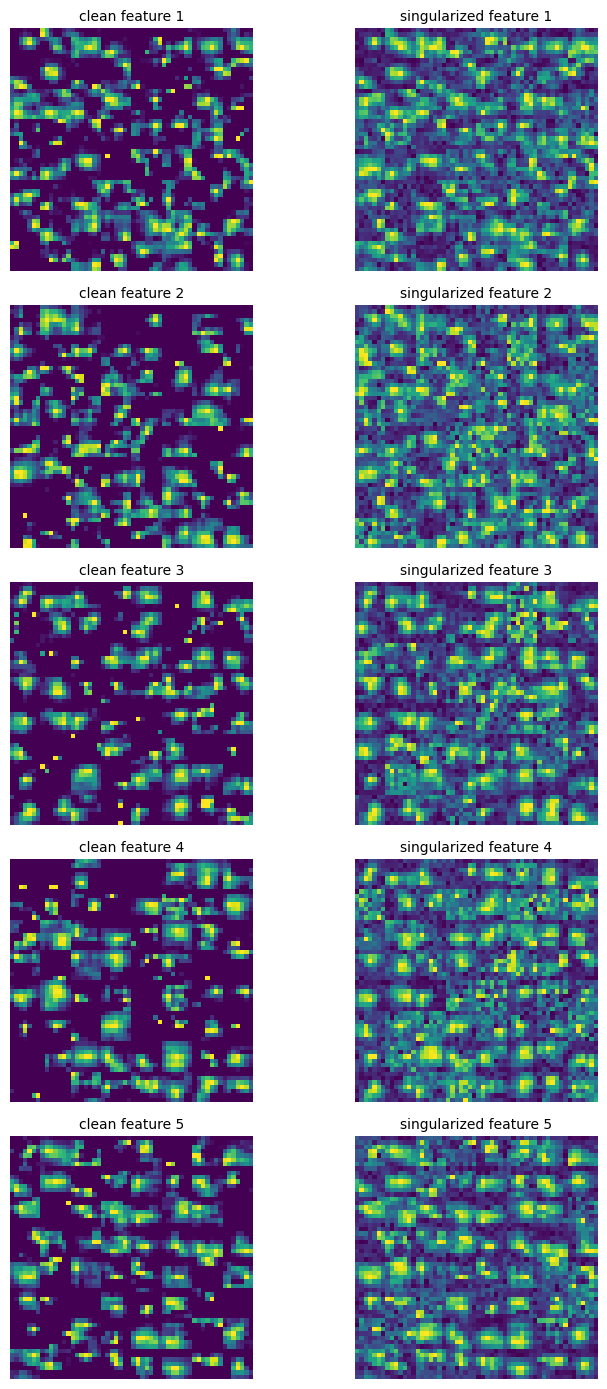

In [9]:
def feature_grid(feat_map, max_channels=64):
    fmap = feat_map.detach().cpu()[:max_channels]
    c, h, w = fmap.shape
    grid_size = int(np.ceil(np.sqrt(c)))
    grid = torch.zeros(grid_size * h, grid_size * w)
    for idx in range(c):
        ch = fmap[idx]
        ch = ch - ch.min()
        denom = ch.max().clamp_min(1e-12)
        ch = ch / denom
        r = idx // grid_size
        col = idx % grid_size
        grid[r*h:(r+1)*h, col*w:(col+1)*w] = ch
    return grid.numpy()


fig, axes = plt.subplots(NUM_VIS, 2, figsize=(8, 14))
for i in range(NUM_VIS):
    axes[i, 0].imshow(feature_grid(clean_fmap[i]), cmap="viridis")
    axes[i, 0].set_title(f"clean feature {i+1}", fontsize=10)
    axes[i, 0].axis("off")
    axes[i, 1].imshow(feature_grid(mix_fmap[i]), cmap="viridis")
    axes[i, 1].set_title(f"singularized feature {i+1}", fontsize=10)
    axes[i, 1].axis("off")
plt.tight_layout()
plt.show()

## Memory Footprint

Singularization replaces a batch tensor with another tensor of the same shape. In image space, the mixed image batch has the same footprint as the clean image batch. In feature space, the mixed feature batch has the same footprint as the clean feature batch. The only small addition is the soft-label tensor.

In [10]:
with torch.no_grad():
    clean_feats = clean_fmap.flatten(1)

memory_rows = [
    ("Clean images", tuple(anchors.shape), tensor_memory_mb(anchors)),
    ("Image-space singularized", tuple(mixed_imgs.shape), tensor_memory_mb(mixed_imgs)),
    ("Clean features", tuple(clean_feats.shape), tensor_memory_mb(clean_feats)),
    ("Feature-space singularized", tuple(mix_feats.shape), tensor_memory_mb(mix_feats.detach().cpu())),
    ("Soft labels", tuple(mix_soft_labels.shape), tensor_memory_mb(mix_soft_labels.detach().cpu())),
]

print(f"{'Tensor':<28} {'Shape':<24} {'Memory (MB)':>12}")
print("-" * 68)
for name, shape, mb in memory_rows:
    print(f"{name:<28} {str(shape):<24} {mb:>12.4f}")

Tensor                       Shape                     Memory (MB)
--------------------------------------------------------------------
Clean images                 (5, 3, 224, 224)               2.8711
Image-space singularized     (5, 3, 224, 224)               2.8711
Clean features               (5, 25088)                     0.4785
Feature-space singularized   (5, 25088)                     0.4785
Soft labels                  (5, 10)                        0.0002


## One-Batch Timing Benchmark

This measures one training batch and breaks time into the components that matter during feature-space training. The important quantity is the singularization/mixup bar: it is just tensor indexing, random noise generation, interpolation, and soft-label construction.

In [11]:
@torch.no_grad()
def infer_embedding_dim(feature_extractor, dataset):
    x, _ = dataset[0]
    fmap = feature_extractor(x.unsqueeze(0).to(device))
    return fmap.flatten(1).size(1)


def timed_one_batch(feature_extractor, classifier, optimizer, imgs, labels, radius):
    timings = OrderedDict()

    sync_if_needed()
    t0 = time.perf_counter()
    imgs = imgs.to(device)
    labels = labels.to(device)
    sync_if_needed()
    timings["data transfer"] = time.perf_counter() - t0

    feature_extractor.eval()
    sync_if_needed()
    t0 = time.perf_counter()
    with torch.no_grad():
        fmap = feature_extractor(imgs)
        feats = fmap.flatten(1)
    sync_if_needed()
    timings["feature extraction"] = time.perf_counter() - t0

    sync_if_needed()
    t0 = time.perf_counter()
    bsz, dim = feats.shape
    idx = torch.arange(bsz, device=device)
    partner = torch.roll(idx, shifts=1)
    lam = 0.3 + 0.4 * torch.rand(bsz, device=device)
    noise = sample_ball_noise((bsz, dim), radius, device=device)
    mix_feats_timed = lam.view(bsz, 1) * feats + (1.0 - lam).view(bsz, 1) * (feats[partner] + noise)
    soft_labels = torch.zeros(bsz, 10, device=device)
    soft_labels[idx, labels] += lam
    soft_labels[idx, labels[partner]] += 1.0 - lam
    sync_if_needed()
    timings["singularization"] = time.perf_counter() - t0

    classifier.train()
    optimizer.zero_grad(set_to_none=True)
    sync_if_needed()
    t0 = time.perf_counter()
    outputs = classifier(mix_feats_timed)
    loss = cross_entropy_with_soft_targets(outputs, soft_labels)
    sync_if_needed()
    timings["classifier + loss"] = time.perf_counter() - t0

    sync_if_needed()
    t0 = time.perf_counter()
    loss.backward()
    optimizer.step()
    sync_if_needed()
    timings["backward + optimizer"] = time.perf_counter() - t0

    return timings, float(loss.item())


timing_subset = Subset(resnet_train, list(range(512)))
timing_loader = DataLoader(timing_subset, batch_size=TIMING_BATCH_SIZE, shuffle=True)
timing_imgs, timing_labels = next(iter(timing_loader))

embedding_dim = infer_embedding_dim(feature_extractor, resnet_train)
classifier = DenseClassifier(embedding_dim, 10).to(device)
optimizer = optim.SGD(classifier.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)

# Warm-up avoids measuring one-time setup costs such as kernel compilation/cache effects.
_ = timed_one_batch(feature_extractor, classifier, optimizer, timing_imgs, timing_labels, feature_radius_for_demo)
timings, loss_value = timed_one_batch(feature_extractor, classifier, optimizer, timing_imgs, timing_labels, feature_radius_for_demo)

total_time = sum(timings.values())
print(f"Loss: {loss_value:.4f}")
print(f"{'Component':<24} {'Seconds':>10} {'Percent':>10}")
print("-" * 48)
for name, seconds in timings.items():
    print(f"{name:<24} {seconds:>10.5f} {100 * seconds / total_time:>9.2f}%")
print("-" * 48)
print(f"{'total':<24} {total_time:>10.5f} {100.0:>9.2f}%")

Loss: 2.4079
Component                   Seconds    Percent
------------------------------------------------
data transfer               0.00193      1.45%
feature extraction          0.12007     89.70%
singularization             0.00250      1.87%
classifier + loss           0.00206      1.54%
backward + optimizer        0.00729      5.45%
------------------------------------------------
total                       0.13385    100.00%


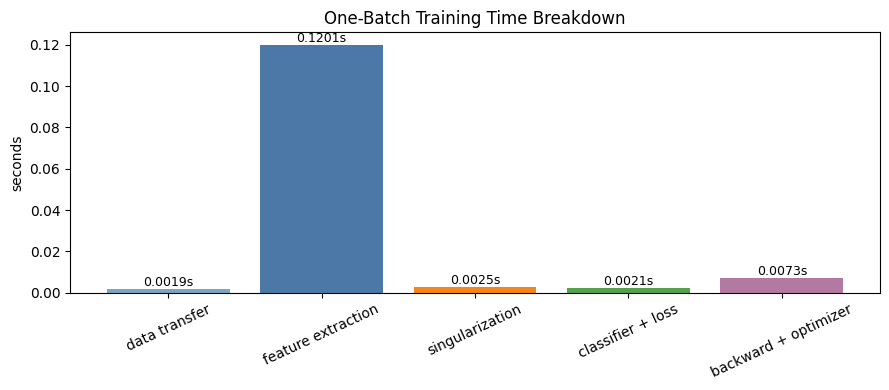

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
names = list(timings.keys())
values = [timings[n] for n in names]
colors = ["#7aa6c2", "#4c78a8", "#f58518", "#54a24b", "#b279a2"]
ax.bar(names, values, color=colors[:len(names)])
ax.set_ylabel("seconds")
ax.set_title("One-Batch Training Time Breakdown")
ax.tick_params(axis="x", rotation=25)
for i, v in enumerate(values):
    ax.text(i, v, f"{v:.4f}s", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## Optional: One-Epoch Smoke Test

This cell is optional for a live presentation. It trains only the dense classifier on a small subset with the frozen feature extractor. The goal is not final accuracy; it is a quick end-to-end sanity check that the singularized feature batches are directly usable for training.

In [13]:
RUN_SMOKE_TRAINING = True

if RUN_SMOKE_TRAINING:
    smoke_subset = Subset(resnet_train, list(range(1024)))
    smoke_loader = DataLoader(smoke_subset, batch_size=128, shuffle=True)
    smoke_classifier = DenseClassifier(embedding_dim, 10).to(device)
    smoke_optimizer = optim.SGD(smoke_classifier.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)

    smoke_classifier.train()
    running_loss = 0.0
    seen = 0
    t0 = time.perf_counter()
    for imgs, labels in smoke_loader:
        smoke_optimizer.zero_grad(set_to_none=True)
        mix_feats_batch, soft_labels_batch = mixup_batch_in_feature_space(
            feature_extractor, imgs, labels, device, feature_radius_for_demo, 10
        )
        logits = smoke_classifier(mix_feats_batch)
        loss = cross_entropy_with_soft_targets(logits, soft_labels_batch)
        loss.backward()
        smoke_optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        seen += imgs.size(0)
    elapsed = time.perf_counter() - t0
    print(f"One small epoch: loss={running_loss/seen:.4f}, time={elapsed:.2f}s, samples={seen}")
else:
    print("Smoke training skipped. Set RUN_SMOKE_TRAINING = True to run it.")

One small epoch: loss=2.3271, time=1.58s, samples=1024


## Takeaway

Singularized mixup is a small tensor operation that can be inserted into a training pipeline with minimal overhead. The simple reconstruction example shows the key intuition: ordinary noiseless mixup can be algebraically inverted when the partner is known, while singularized mixup turns the same inversion into a noisy reconstruction. In the repository implementation, the same principle is applied efficiently in feature space with frozen pretrained representations.